In [52]:
import numpy as np
import matplotlib.pyplot as plt

import reservoirpy
from reservoirpy.mat_gen import uniform
from reservoirpy.nodes import Reservoir, Ridge, ScikitLearnNode
from reservoirpy.observables import spectral_radius
from sklearn.linear_model import Lasso

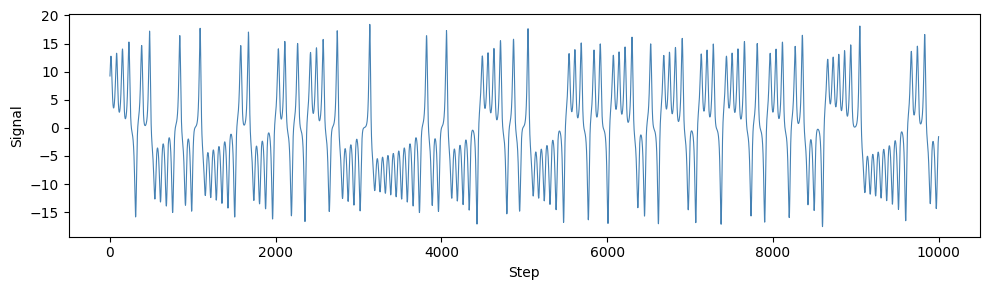

In [53]:
dataset = np.loadtxt('../data/chaotic_data/lorenz_system.csv', delimiter=',')
dataset = dataset[: ,0]

# Visualize the chaotic time series
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(dataset[:], color='steelblue', linewidth=0.8)
ax.set_xlabel('Step')
ax.set_ylabel('Signal')
plt.tight_layout()
plt.show()

/Users/artun/Documents/GitHub/network-reconstruction/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.971e+01, tolerance: 1.841e+01
  model = cd_fast.enet_coordinate_descent(


Train interval : [0 : 3000]
Test interval  : [3000 : 8000]
Warmup length  : 500
Pred. length   : 4500
MSE   : 98.9971051135
RMSE  : 9.9497288965
NRMSE : 1.2555935266


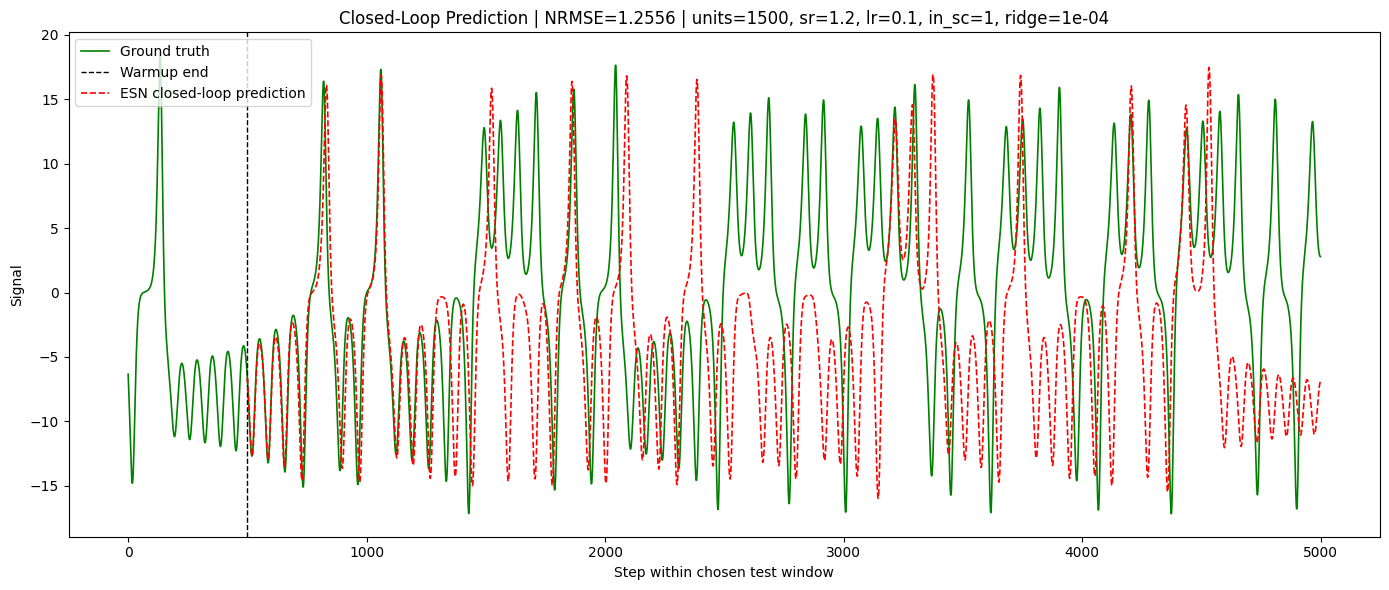

In [55]:
# USER PARAMETERS
train_len = 3000   # training uses data[0:train_len]
test_start = 3000  # start index of test window in the full dataset
test_len = 5000     # total length of chosen test window
warmup_len = 500   # first part of test window used for synchronization

# Regression coefficient
# Typical ranges:
#    Ridge: 1e-8 → 1e-2
#    Lasso: 1e-6 → 1e-1
regression = 1e-4
regression_model = "lasso"  # "ridge" or "lasso"

res_units = 1500
leak_rate = 0.1
spectral_radius = 1.2
input_scaling = 1
seed = 42

# DATA PREPARATION
data = dataset.reshape(-1, 1)
X = data[:-1]
Y = data[1:]

X_train = X[:train_len]
Y_train = Y[:train_len]

X_test = X[test_start:test_start + test_len]
Y_test = Y[test_start:test_start + test_len]

# ESN DEFINITION
reservoir = Reservoir(
    units=res_units,
    lr=leak_rate,
    W=uniform(low=-0.5, high=0.5, connectivity=1.0, sr=spectral_radius),
    Win=uniform(low=-0.5 * input_scaling,
                high=0.5 * input_scaling, connectivity=1.0),
    bias=uniform(low=-0.5, high=0.5, connectivity=1.0),
    activation="tanh",
    seed=seed
)

if regression_model == "ridge":
    readout = Ridge(ridge=regression)
else: 
    readout = ScikitLearnNode(model=Lasso, alpha=regression, max_iter=10000)
esn = reservoir >> readout

# TRAINING
esn.fit(X_train, Y_train, warmup=100)

# TESTING
esn.reset()

if warmup_len > 0:
    esn.run(X_test[:warmup_len])

pred_len = test_len - warmup_len
Y_pred = []

current_input = X_test[warmup_len:warmup_len + 1]  # first seed after warmup

for _ in range(pred_len):
    pred = esn.run(current_input)
    pred = np.asarray(pred).reshape(1, -1)
    Y_pred.append(pred[0, 0])
    current_input = pred  # closed-loop feedback

Y_pred = np.array(Y_pred)
Y_true = Y_test[warmup_len:warmup_len + pred_len, 0]

# ERROR METRICS
mse = np.mean((Y_true - Y_pred) ** 2)
rmse = np.sqrt(mse)
nrmse = rmse / np.std(Y_true)

print(f"Train interval : [0 : {train_len}]")
print(f"Test interval  : [{test_start} : {test_start + test_len}]")
print(f"Warmup length  : {warmup_len}")
print(f"Pred. length   : {pred_len}")
print(f"MSE   : {mse:.10f}")
print(f"RMSE  : {rmse:.10f}")
print(f"NRMSE : {nrmse:.10f}")

# VISUALIZATION
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(np.arange(test_len), Y_test[:, 0], c='green', label="Ground truth", linewidth=1.2)
ax.axvline(warmup_len, linestyle="--", c='k', linewidth=1.0, label="Warmup end")
ax.plot(np.arange(warmup_len, warmup_len + pred_len), Y_pred, linestyle="--", c='red', linewidth=1.2, label="ESN closed-loop prediction")
ax.set_title(
    f"Closed-Loop Prediction | NRMSE={nrmse:.4f} | "
    f"units={res_units}, sr={spectral_radius}, "
    f"lr={leak_rate}, in_sc={input_scaling}, "
    f"reg={regression:.0e}"
)
ax.set_xlabel("Step within chosen test window")
ax.set_ylabel("Signal")
ax.legend()
plt.tight_layout()
plt.show()